# 1. Loan Default Risk Prediction & Scoring Engine

This project builds an end-to-end machine learning system to predict borrower default risk using 1.3M+ historical loan records from Lending Club. 

The objective is to estimate probability of default and convert it into a business-friendly risk score.

---
## 1. Setup & Imports

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, precision_recall_curve,
    average_precision_score, confusion_matrix
)
from xgboost import XGBClassifier
import shap
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Load Data

In [41]:
# Update path to your local file if running outside Kaggle
df_raw = pd.read_csv('/kaggle/input/datasets/azimsadath521/loan-dataset/loan.csv', low_memory=False)

print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head(3)

Raw dataset shape: (2260668, 145)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0000,36 months,13.5600,84.9200,C,C1,Chef,10+ years,RENT,55000.0000,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.2400,0.0000,Apr-2001,1.0000,NaN,45.0000,9.0000,1.0000,4341,10.3000,34.0000,w,2386.0200,2386.0200,167.0200,167.0200,113.9800,53.0400,0.0000,0.0000,0.0000,Feb-2019,84.9200,Mar-2019,Feb-2019,0.0000,NaN,1,Individual,NaN,NaN,NaN,0.0000,0.0000,16901.0000,2.0000,2.0000,1.0000,2.0000,2.0000,12560.0000,69.0000,2.0000,7.0000,2137.0000,28.0000,42000.0000,1.0000,11.0000,2.0000,9.0000,1878.0000,34360.0000,5.9000,0.0000,0.0000,140.0000,212.0000,1.0000,1.0000,0.0000,1.0000,NaN,2.0000,NaN,0.0000,2.0000,5.0000,3.0000,3.0000,16.0000,7.0000,18.0000,5.0000,9.0000,0.0000,0.0000,0.0000,3.0000,100.0000,0.0000,1.0000,0.0000,60124.0000,16901.0000,36500.0000,18124.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0000,60 months,18.9400,777.2300,D,D2,Postmaster,10+ years,MORTGAGE,90000.0000,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.5200,0.0000,Jun-1987,0.0000,71.0000,75.0000,13.0000,1.0000,12315,24.2000,44.0000,w,29387.7500,29387.7500,1507.1100,1507.1100,612.2500,894.8600,0.0000,0.0000,0.0000,Feb-2019,777.2300,Mar-2019,Feb-2019,0.0000,NaN,1,Individual,NaN,NaN,NaN,0.0000,1208.0000,321915.0000,4.0000,4.0000,2.0000,3.0000,3.0000,87153.0000,88.0000,4.0000,5.0000,998.0000,57.0000,50800.0000,2.0000,15.0000,2.0000,10.0000,24763.0000,13761.0000,8.3000,0.0000,0.0000,163.0000,378.0000,4.0000,3.0000,3.0000,4.0000,NaN,4.0000,NaN,0.0000,2.0000,4.0000,4.0000,9.0000,

---
## 3. Target Variable Creation

Filter to finalized loans only (Fully Paid / Charged Off) and create a binary target:
- `0` → Fully Paid
- `1` → Default (Charged Off)

In [42]:
print('All loan statuses:')
print(df_raw['loan_status'].value_counts())

All loan statuses:
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


In [43]:
# Keep only finalized loans
df = df_raw[df_raw['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Create binary target
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)
df.drop('loan_status', axis=1, inplace=True)

print(f'Filtered dataset shape: {df.shape}')
print(f'Default rate: {df["default"].mean():.2%}')

Filtered dataset shape: (1303607, 145)
Default rate: 20.07%


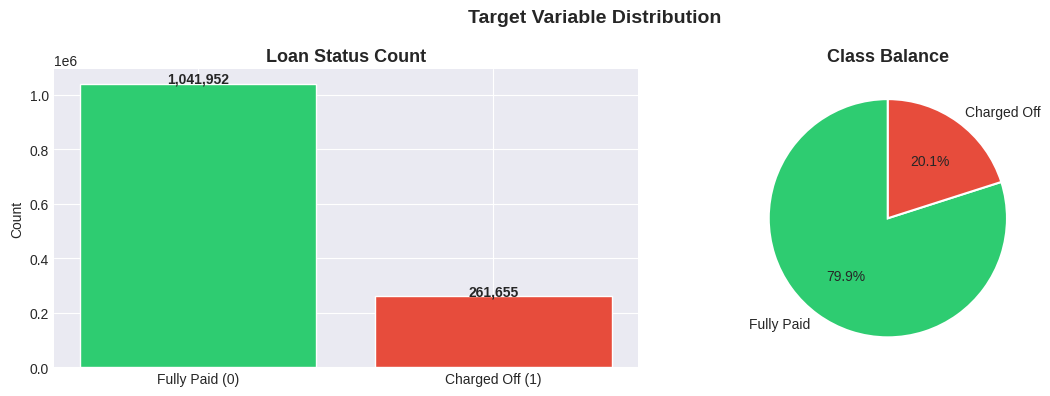

Class ratio (Paid:Default) = 4.0:1


In [44]:
# Visualize class balance
counts = df['default'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Fully Paid (0)', 'Charged Off (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Loan Status Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Fully Paid', 'Charged Off'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Class ratio (Paid:Default) = {counts[0]/counts[1]:.1f}:1')

> **Finding:** ~80% fully paid, ~20% default. We handle this imbalance using `scale_pos_weight` in XGBoost — no resampling needed, all 1.3M records preserved.

---
## 4. Feature Selection

Select only columns available at **loan application time** — this prevents data leakage from post-outcome columns like `total_pymnt`, `recoveries`, etc.

In [45]:
selected_cols = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'addr_state',
    'dti',
    'delinq_2yrs',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'mort_acc',
    'pub_rec_bankruptcies',
    'default'
]

# Keep only columns that exist in the dataset
selected_cols = [c for c in selected_cols if c in df.columns]
df = df[selected_cols].copy()

print(f'Shape after feature selection: {df.shape}')
print(f'Features selected: {len(selected_cols) - 1}')

Shape after feature selection: (1303607, 22)
Features selected: 21


---
## 5. Missing Value Analysis

In [46]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print(missing_df)

Columns with missing values: 5
                      Missing Count  Missing %
emp_length                    75454     5.7900
mort_acc                      47281     3.6300
revol_util                      810     0.0600
pub_rec_bankruptcies            697     0.0500
dti                             312     0.0200


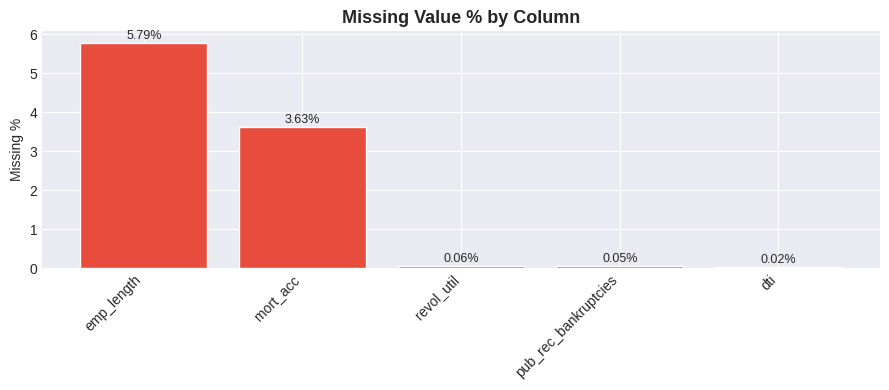

In [47]:
# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(9, 4))
    plt.bar(missing_df.index, missing_df['Missing %'], color='#e74c3c', edgecolor='white')
    plt.title('Missing Value % by Column', fontsize=13, fontweight='bold')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(missing_df['Missing %']):
        plt.text(i, v + 0.1, f'{v}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 6.Data Cleaning

In [48]:
# Clean employment length — extract numeric value
df['emp_length'] = (
    df['emp_length']
    .astype(str)
    .str.replace('years', '', regex=False)
    .str.replace('year', '', regex=False)
    .str.replace('+', '', regex=False)
    .str.replace('< 1', '0', regex=False)
    .str.strip()
)
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')
df['emp_length'].fillna(df['emp_length'].median(), inplace=True)

# Median imputation for remaining numeric columns
num_cols = ['mort_acc', 'revol_util', 'pub_rec_bankruptcies', 'dti', 'total_acc']
num_cols = [c for c in num_cols if c in df.columns]
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print(f'Missing values remaining: {df.isnull().sum().sum()}')

Missing values remaining: 0


---
## 7. Exploratory Data Analysis

Visualizing key financial features by default status to understand which variables best separate defaulters from non-defaulters.

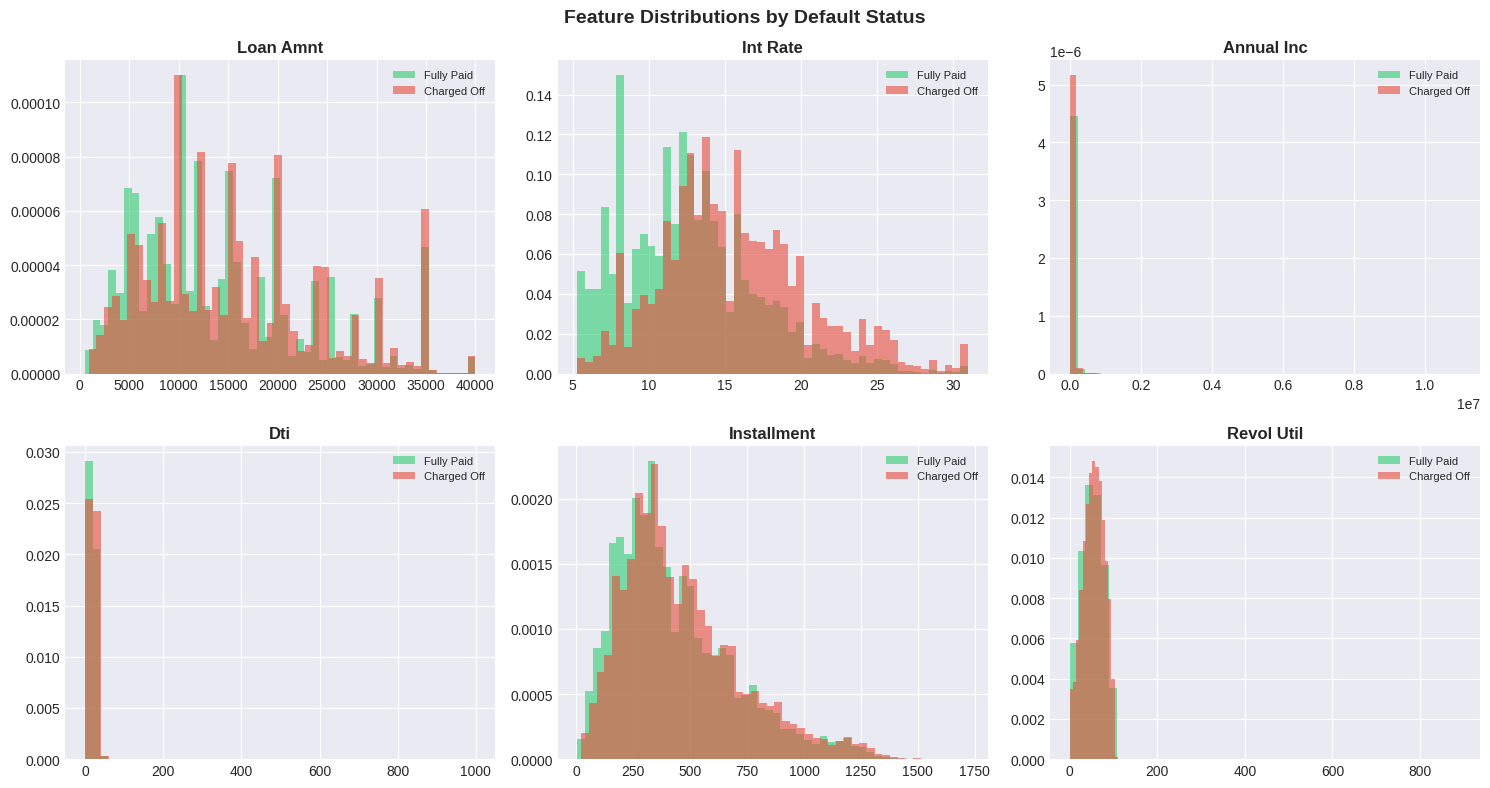

In [49]:
# Feature distributions by default status
key_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'revol_util']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    paid = df[df['default'] == 0][feat].dropna()
    defaulted = df[df['default'] == 1][feat].dropna()
    axes[i].hist(paid, bins=50, alpha=0.6, color='#2ecc71', label='Fully Paid', density=True)
    axes[i].hist(defaulted, bins=50, alpha=0.6, color='#e74c3c', label='Charged Off', density=True)
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

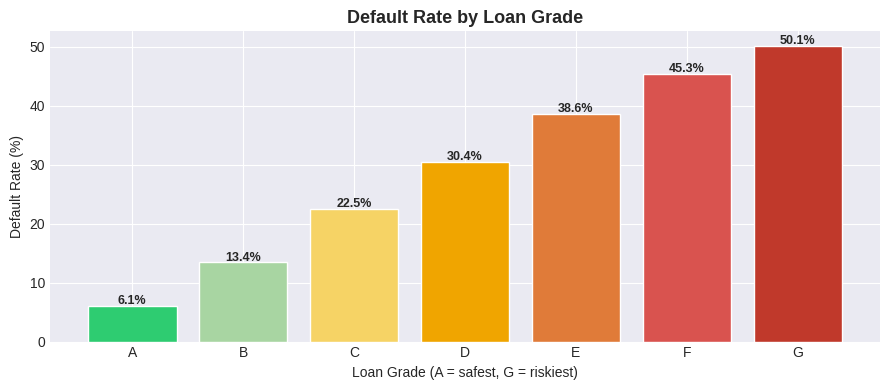

In [50]:
# Default rate by loan grade
if 'grade' in df.columns:
    grade_default = df.groupby('grade')['default'].mean().sort_index() * 100
    colors = ['#2ecc71', '#a8d5a2', '#f6d365', '#f0a500', '#e07b39', '#d9534f', '#c0392b']

    plt.figure(figsize=(9, 4))
    bars = plt.bar(grade_default.index, grade_default.values,
                   color=colors[:len(grade_default)], edgecolor='white')
    plt.title('Default Rate by Loan Grade', fontsize=13, fontweight='bold')
    plt.ylabel('Default Rate (%)')
    plt.xlabel('Loan Grade (A = safest, G = riskiest)')
    for bar, val in zip(bars, grade_default.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

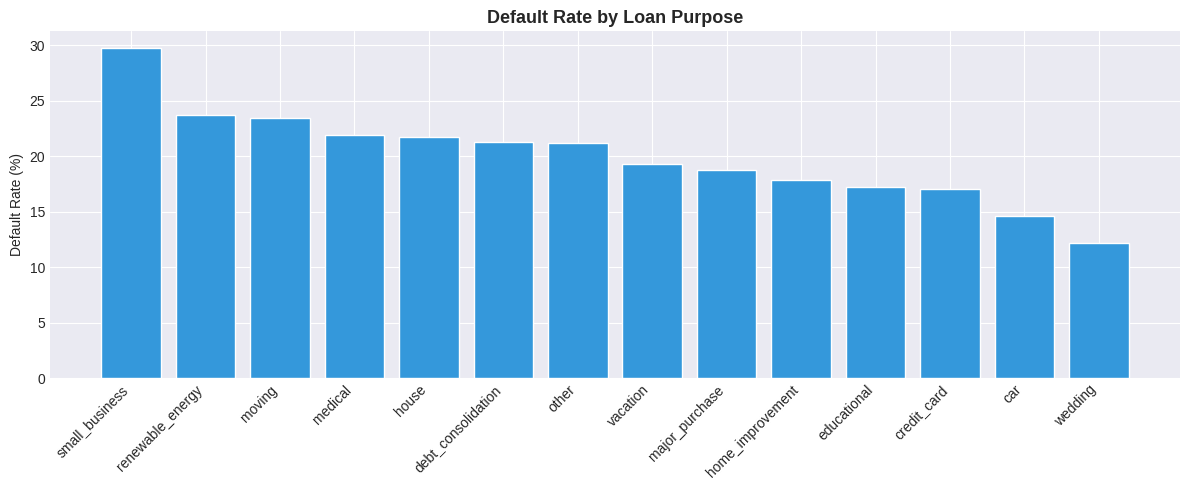

In [51]:
# Default rate by loan purpose
if 'purpose' in df.columns:
    purpose_default = df.groupby('purpose')['default'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(12, 5))
    bars = plt.bar(purpose_default.index, purpose_default.values,
                   color='#3498db', edgecolor='white')
    plt.title('Default Rate by Loan Purpose', fontsize=13, fontweight='bold')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

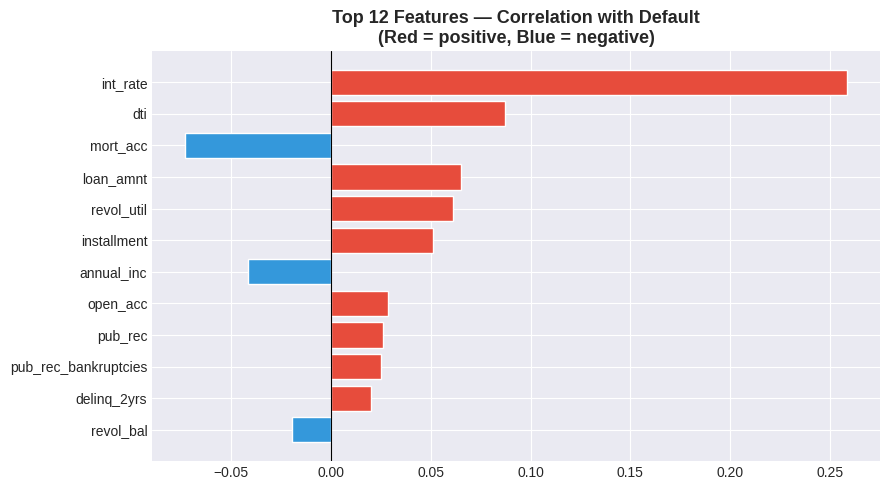

In [52]:
# Correlation with target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()['default'].drop('default')
corr_sorted = corr.abs().sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if corr[c] > 0 else '#3498db' for c in corr_sorted.index]
plt.barh(corr_sorted.index, corr[corr_sorted.index], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 12 Features — Correlation with Default\n(Red = positive, Blue = negative)', 
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Feature Engineering

Creating financial stress indicators that better capture borrower risk than raw features alone.

| Feature | Formula | Why it matters |
|---|---|---|
| loan_to_income | loan_amnt / annual_inc | How large the loan is relative to income |
| installment_to_income | installment / (annual_inc/12) | Monthly payment burden vs monthly income |
| revol_bal_to_income | revol_bal / annual_inc | Revolving debt load relative to income |
| grade_num | A=1 → G=7 | Numeric encoding of credit grade |

In [54]:
# Loan-to-Income Ratio
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# Installment-to-Income Ratio (installment is monthly, so divide annual_inc by 12)
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# Revolving Balance-to-Income Ratio
df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)

# Ordinal encoding of loan grade (A=1 safest, G=7 riskiest)
if 'grade' in df.columns:
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df['grade_num'] = df['grade'].map(grade_map)
    df.drop('grade', axis=1, inplace=True)

print('Engineered features added successfully.')
print(f'New shape: {df.shape}')
df[['loan_to_income', 'installment_to_income', 'revol_bal_to_income']].describe()

Engineered features added successfully.
New shape: (1303607, 25)


,loan_to_income,installment_to_income,revol_bal_to_income
count,1303607.0000,1303607.0000,1303607.0000
mean,4.2014,0.1983,3.5086
std,303.9057,8.9142,343.7296
min,0.0002,0.0001,0.0000
25%,0.1250,0.0464,0.0985
50%,0.2000,0.0723,0.1796
75%,0.2909,0.1055,0.2956
max,40000.0000,1466.8500,181809.0000


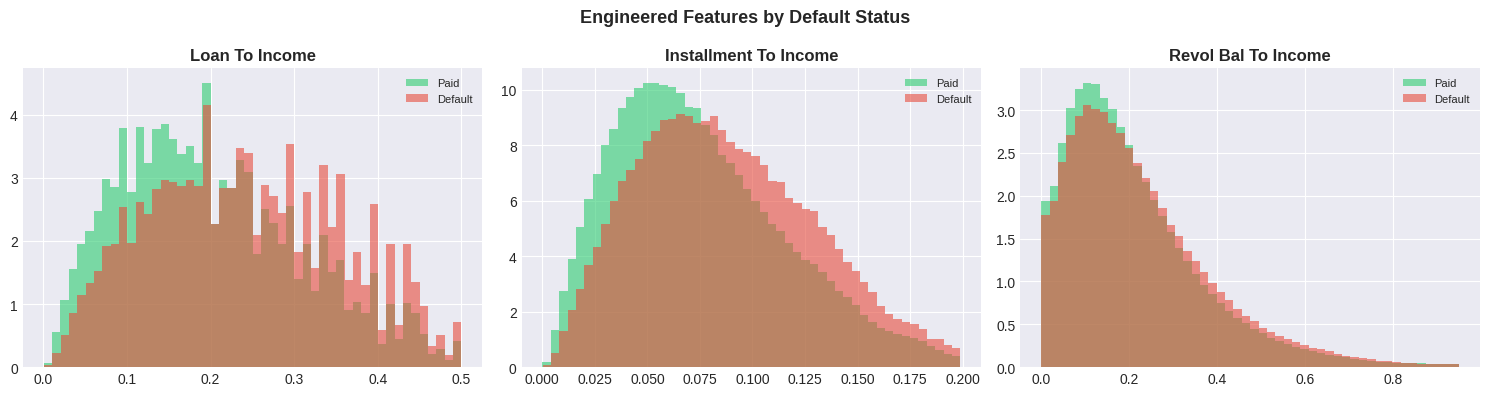

In [55]:
# Visualize engineered features vs default rate
eng_features = ['loan_to_income', 'installment_to_income', 'revol_bal_to_income']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(eng_features):
    paid = df[df['default'] == 0][feat].dropna()
    defaulted = df[df['default'] == 1][feat].dropna()
    # Cap at 99th percentile for cleaner plots
    cap = df[feat].quantile(0.99)
    axes[i].hist(paid[paid <= cap], bins=50, alpha=0.6, color='#2ecc71', label='Paid', density=True)
    axes[i].hist(defaulted[defaulted <= cap], bins=50, alpha=0.6, color='#e74c3c', label='Default', density=True)
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Engineered Features by Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Preprocessing & Train/Test Split

In [56]:
X = df.drop('default', axis=1)
y = df['default']

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Stratified train/test split — preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Default rate in train: {y_train.mean():.2%}')
print(f'Default rate in test:  {y_test.mean():.2%}')

Training set: (1042885, 123)
Test set:     (260722, 123)
Default rate in train: 20.07%
Default rate in test:  20.07%


---
## 10. Model Training & Comparison

Training three models and comparing ROC-AUC performance.

In [57]:
# --- Logistic Regression ---
print('Training Logistic Regression...')
log_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
auc_log = roc_auc_score(y_test, y_prob_log)
print(f'Logistic Regression ROC-AUC: {auc_log:.4f}')

Training Logistic Regression...
Logistic Regression ROC-AUC: 0.7090


In [58]:
# --- Random Forest ---
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f'Random Forest ROC-AUC: {auc_rf:.4f}')

Training Random Forest...
Random Forest ROC-AUC: 0.7066


In [59]:
# --- XGBoost with scale_pos_weight to handle imbalance ---
print('Training XGBoost...')
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {ratio:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f'XGBoost ROC-AUC: {auc_xgb:.4f}')

Training XGBoost...
scale_pos_weight = 3.98
XGBoost ROC-AUC: 0.7203


In [60]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [auc_log, auc_rf, auc_xgb]
}).sort_values('ROC-AUC', ascending=False)

print('\n=== Model Comparison ===')
print(results.to_string(index=False))


=== Model Comparison ===
              Model  ROC-AUC
            XGBoost   0.7203
Logistic Regression   0.7090
      Random Forest   0.7066


---
## 11. Model Evaluation

Detailed evaluation of the best model (XGBoost).

In [61]:
# Classification report
y_pred_xgb = xgb_model.predict(X_test)
print('XGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Fully Paid', 'Charged Off']))

XGBoost Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.89      0.64      0.75    208391
 Charged Off       0.32      0.68      0.44     52331

    accuracy                           0.65    260722
   macro avg       0.60      0.66      0.59    260722
weighted avg       0.77      0.65      0.68    260722



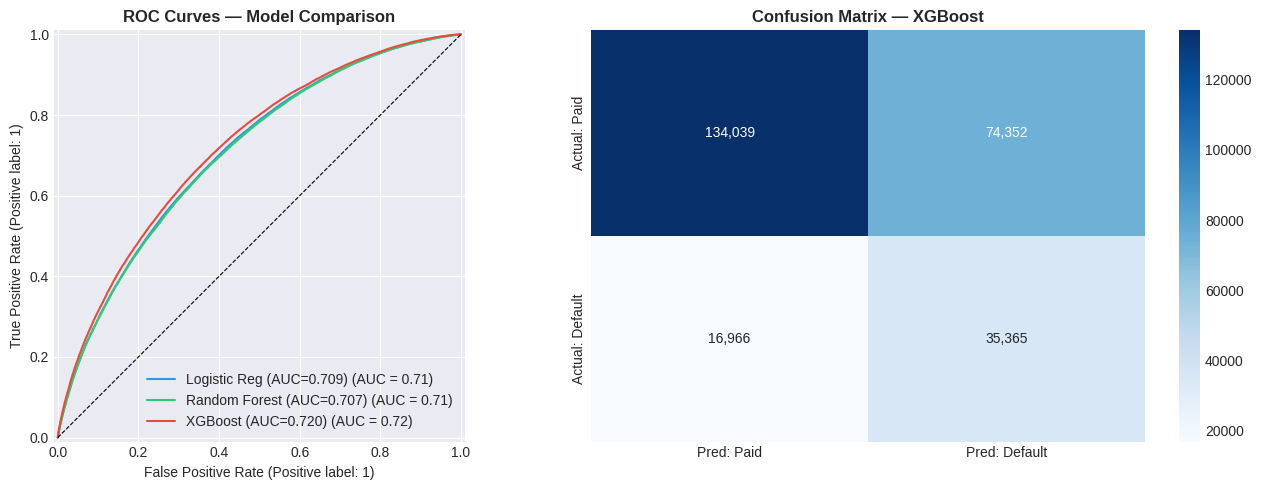

In [62]:
# ROC Curves — all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_log, name=f'Logistic Reg (AUC={auc_log:.3f})', ax=axes[0], color='#3498db')
RocCurveDisplay.from_predictions(y_test, y_prob_rf,  name=f'Random Forest (AUC={auc_rf:.3f})',  ax=axes[0], color='#2ecc71')
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name=f'XGBoost (AUC={auc_xgb:.3f})',       ax=axes[0], color='#e74c3c')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold')

# Confusion matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: Paid', 'Pred: Default'],
            yticklabels=['Actual: Paid', 'Actual: Default'])
axes[1].set_title('Confusion Matrix — XGBoost', fontweight='bold')

plt.tight_layout()
plt.show()

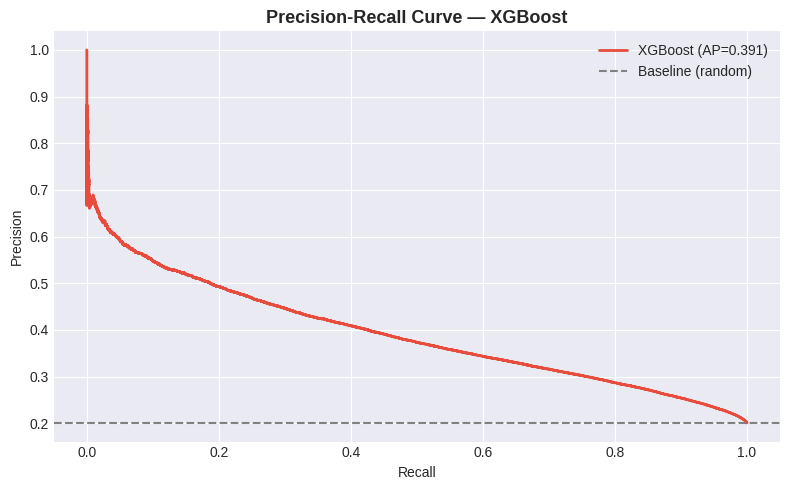

In [63]:
# Precision-Recall curve (better metric for imbalanced data)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)
ap = average_precision_score(y_test, y_prob_xgb)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='#e74c3c', linewidth=2, label=f'XGBoost (AP={ap:.3f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label='Baseline (random)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 12. SHAP Explainability

SHAP (SHapley Additive exPlanations) tells us which features are driving each prediction — making the model interpretable for business use.

In [64]:
# SHAP on a sample of test data (full set is slow)
print('Computing SHAP values...')
sample_idx = np.random.choice(len(X_test), size=2000, replace=False)
X_test_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)
print('Done.')

Computing SHAP values...
Done.


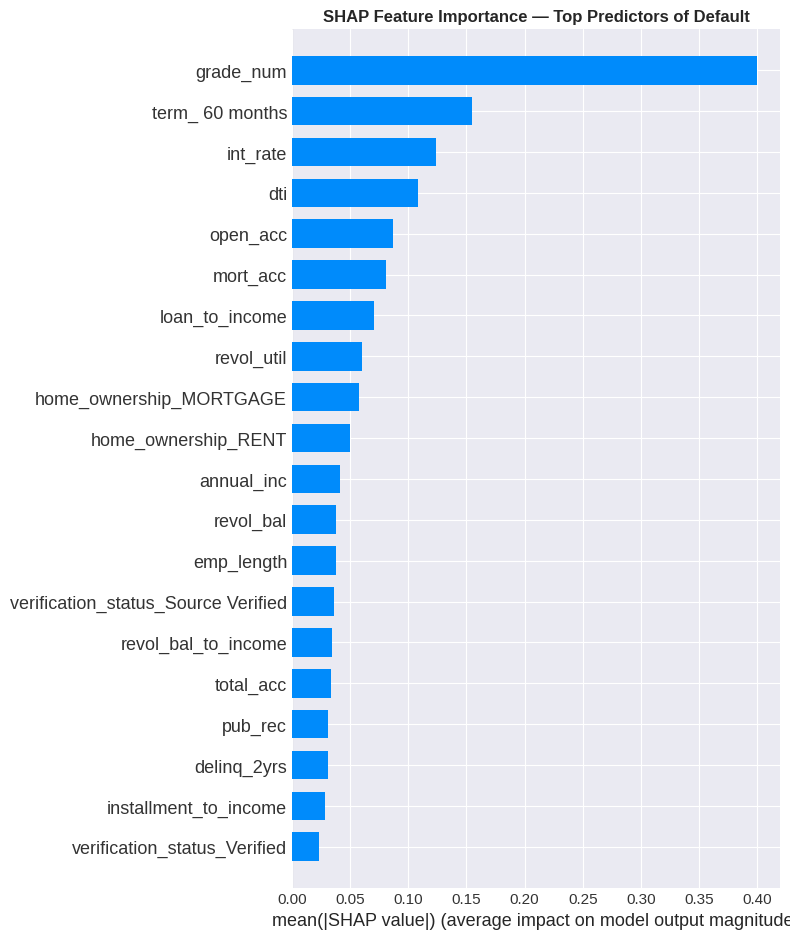

In [65]:
# SHAP Summary Plot — global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Top Predictors of Default', fontweight='bold')
plt.tight_layout()
plt.show()

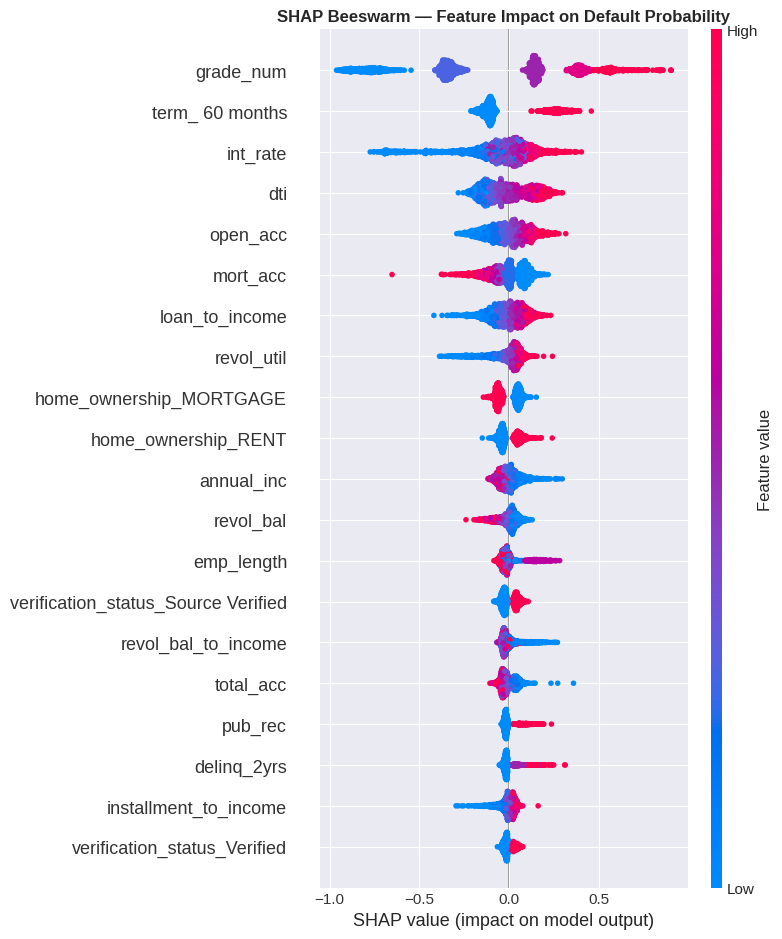

In [66]:
# SHAP Beeswarm — shows direction of impact
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Default Probability', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Risk Scoring

Converting predicted probability into a business-friendly 0–100 risk score.

In [67]:
def risk_category(score):
    if score < 30:
        return 'Low Risk'
    elif score < 60:
        return 'Medium Risk'
    else:
        return 'High Risk'

df_scores = pd.DataFrame({
    'probability_of_default': y_prob_xgb,
    'risk_score': (y_prob_xgb * 100).round(2),
    'actual_default': y_test.values
})
df_scores['risk_category'] = df_scores['risk_score'].apply(risk_category)

print('Risk Score Distribution:')
print(df_scores['risk_category'].value_counts())
print()
df_scores.head(10)

Risk Score Distribution:
risk_category
Medium Risk    136324
High Risk       63712
Low Risk        60686
Name: count, dtype: int64



,probability_of_default,risk_score,actual_default,risk_category
0,0.3618,36.1800,0,Medium Risk
1,0.3793,37.9300,0,Medium Risk
2,0.0411,4.1100,0,Low Risk
3,0.6567,65.6700,0,High Risk
4,0.4815,48.1500,1,Medium Risk
5,0.6259,62.5900,0,High Risk
6,0.7808,78.0800,0,High Risk
7,0.0947,9.4700,0,Low Risk
8,0.6279,62.7900,0,High Risk
9,0.6599,65.9900,0,High Risk


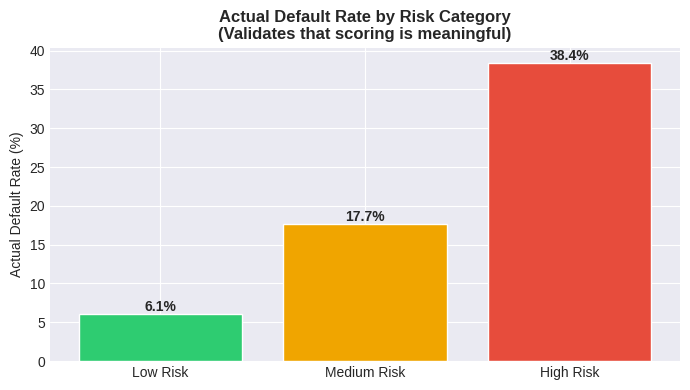

In [68]:
# Default rate within each risk category — validation check
category_validation = df_scores.groupby('risk_category')['actual_default'].mean() * 100
category_validation = category_validation.reindex(['Low Risk', 'Medium Risk', 'High Risk'])

plt.figure(figsize=(7, 4))
bars = plt.bar(category_validation.index, category_validation.values,
               color=['#2ecc71', '#f0a500', '#e74c3c'], edgecolor='white')
plt.title('Actual Default Rate by Risk Category\n(Validates that scoring is meaningful)', 
          fontweight='bold')
plt.ylabel('Actual Default Rate (%)')
for bar, val in zip(bars, category_validation.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14. Save Model

In [69]:
joblib.dump(xgb_model, 'xgb_loan_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Saved:')
print('  xgb_loan_model.pkl')
print('  feature_columns.pkl')
print('  scaler.pkl')

import os
print('\nFiles in working directory:')
print(os.listdir('.'))

Saved:
  xgb_loan_model.pkl
  feature_columns.pkl
  scaler.pkl

Files in working directory:
['xgb_loan_model.pkl', 'scaler.pkl', '.virtual_documents', 'feature_columns.pkl']


---
## Key Findings

| Finding | Detail |
|---|---|
| Dataset size | 1.3M+ finalized loans |
| Class imbalance | 80% fully paid / 20% default |
| Best model | XGBoost with `scale_pos_weight` |
| Best AUC | See results above |
| Top risk drivers | Interest rate, loan grade, DTI, loan-to-income ratio |
| Leakage prevention | Only pre-application features used |
| Business output | 0–100 risk score with Low / Medium / High categories |